# No Single Tool Runs the Pipeline
## AI Tool Evaluation Demo — Hallway Hunters Asset Pipeline
**Preeta Chatterjee | CSYE 7270: Building Virtual Environments | Northeastern University**

---

### Topic Claim
After reading this piece, a practitioner will understand how to evaluate and combine AI tools across a survival horror game's asset and animation pipeline well enough to choose the right tool for each production stage, without assuming any single AI tool handles all creative decisions equally well — and without burning hours on tool-category mismatches that no amount of prompt iteration will fix.

---

### What This Notebook Demonstrates
This notebook documents five real AI tool evaluation decisions made during production of **Hallway Hunters**, a first-person survival horror game in Unreal Engine 5. Each decision point shows:
- The prompt used
- The tool(s) evaluated
- The output received
- The decision made and the reasoning behind it

**Decision Point 3 (Walk Cycle Flipbook) is the triggered failure case.** It is reproduced here so a reader can verify the structural limit themselves.

**Decision Point 4 (Blood Splatter Material) contains the Human Decision Node.**

---

### Scope: Accessibility Over Capability Ceiling

This evaluation covers tools available without a paid subscription: **ChatGPT (free tier with image generation), Gemini, and Claude.**

Paid tools such as Midjourney, Adobe Firefly, or dedicated sprite animation platforms may produce higher-fidelity outputs in some categories. They are not evaluated here because **accessibility is part of the pipeline decision.** A tool that requires a subscription not every developer can afford is not a general solution — it is a solution for developers who can pay for it. The decisions documented here are replicable by any developer with a standard internet connection and no paid accounts.

One clarification matters: where paid tools might close a gap, it is typically a **quality gap** (higher resolution, more consistent style). They do not close the **structural gap** in Decision Point 3. No payment tier of any current image generator solves the frame continuity problem — that failure is architectural, not a gated feature.

---
## Setup
This notebook uses `Pillow` to display saved output images inline. All AI outputs shown are real outputs from production — saved during development of Hallway Hunters.

In [43]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/CSYE7270_Midterm')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import os

def show_image(path, title='', figsize=(10, 6)):
    """Display an image with a title."""
    if os.path.exists(path):
        img = mpimg.imread(path)
        fig, ax = plt.subplots(figsize=figsize)
        ax.imshow(img)
        ax.axis('off')
        if title:
            ax.set_title(title, fontsize=12, pad=10)
        plt.tight_layout()
        plt.show()
    else:
        print(f'[PLACEHOLDER] Image not yet added: {path}')
        print(f'  → Replace this path with your actual image file before submission.')

def show_comparison(path_a, label_a, path_b, label_b, figsize=(14, 6)):
    """Display two images side by side for comparison."""
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    for ax, path, label in zip(axes, [path_a, path_b], [label_a, label_b]):
        if os.path.exists(path):
            ax.imshow(mpimg.imread(path))
        else:
            ax.text(0.5, 0.5, f'[PLACEHOLDER]\n{path}', ha='center', va='center',
                    transform=ax.transAxes, fontsize=10, color='gray',
                    bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.8))
        ax.axis('off')
        ax.set_title(label, fontsize=11, pad=8)
    plt.tight_layout()
    plt.show()

print('Setup complete.')

Setup complete.


---
## Decision Point 1: Floor Plan Generation
**Task:** Generate an accurate floor plan of the Hallway Hunters apartment building layout, including interior room layouts, matching a hand-drawn reference image.

**Tools evaluated:** Claude, ChatGPT (GPT-4o)

**Expected output:** A white-background, black-line floor plan that accurately reflects the spatial relationships in the reference.

In [45]:
# Prompts sent to both tools — identical across both iterations

prompt_v1 = """
Using this as a reference, help me create a floor plan for this apartment floor,
including the floor plans of the different apartment interiors as well.
The space beside apartment 105 is the staircase.
"""

prompt_v2 = """
Using this as a reference, help me create a floor plan for this apartment floor,
including the floor plans of the different apartment interiors as well.
The space beside apartment 105 is the staircase.
The image should be on a white background, with black lines,
just how I have kept in the reference.
"""

print('Prompt v1 (sent with reference image):')
print(prompt_v1)
print('Prompt v2 (added styling constraint):')
print(prompt_v2)

Prompt v1 (sent with reference image):

Using this as a reference, help me create a floor plan for this apartment floor,
including the floor plans of the different apartment interiors as well.
The space beside apartment 105 is the staircase.

Prompt v2 (added styling constraint):

Using this as a reference, help me create a floor plan for this apartment floor,
including the floor plans of the different apartment interiors as well.
The space beside apartment 105 is the staircase.
The image should be on a white background, with black lines,
just how I have kept in the reference.



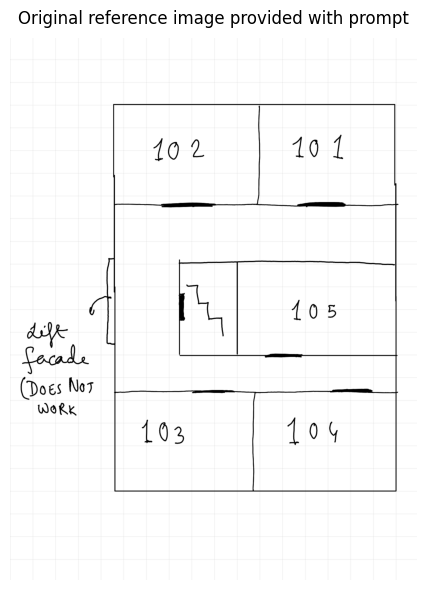

In [46]:
# Show the original reference image that was provided with the prompt
show_image(
    'images/floor_hallway_reference.png',  # your reference image — update filename if different
    'Original reference image provided with prompt',
    figsize=(10, 6)
)

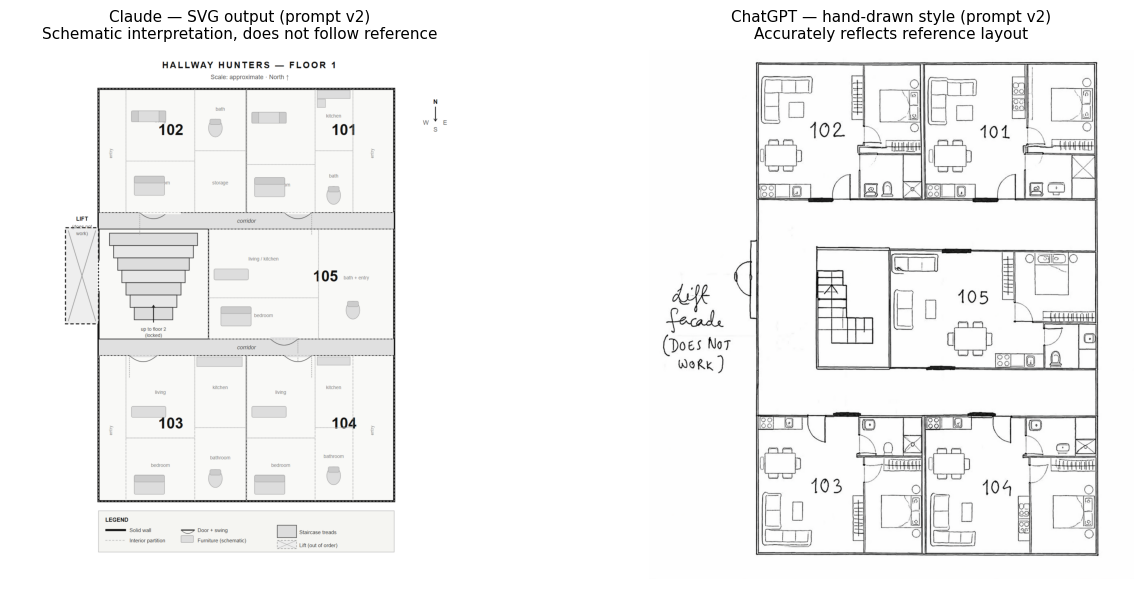

In [47]:
# Claude output — v1: dark background PDF that did not follow the reference correctly
# Claude output — v2: SVG file on white background, same schematic interpretation as v1
# ChatGPT output — v2: hand-drawn style floor plan, white background, reference-accurate

show_comparison(
    'images/claude_floorplan_svg.png',  # REPLACE: screenshot of Claude's SVG output
    'Claude — SVG output (prompt v2)\nSchematic interpretation, does not follow reference',
    'images/chatgpt_floorplan.png',     # REPLACE: ChatGPT's floor plan output
    'ChatGPT — hand-drawn style (prompt v2)\nAccurately reflects reference layout'
)

### Decision 1: ChatGPT selected for spatial documents

**What happened:** Claude attempted the task across two formats (PDF, then SVG) and two prompt iterations. Both outputs applied Claude's own schematic interpretation of the layout rather than accurately reading the reference image. The SVG was geometrically readable but did not reflect the actual room positions and dimensions from the reference.

ChatGPT produced a hand-drawn style floor plan that accurately reflected the spatial relationships in the reference on the second prompt.

**Decision:** ChatGPT for any task requiring accurate reference image fidelity in spatial documents.

**Why this is not a quality comparison:** Claude is a language model that can generate structured files (SVG, PDF) but does not have image generation capability in the same pipeline as ChatGPT. The mismatch is architectural, not qualitative. Claude belongs in the pipeline for language output — steps, logic, prompts. Not for image output requiring visual reference fidelity.

---
## Decision Point 2: Zombie Rig Body Parts Reference Sheet
**Task:** Generate a 2D zombie character broken into isolated body parts (head, torso, arms, legs) suitable for rigged sprite animation — parts must be connectable and visually consistent.

**Tools evaluated:** ChatGPT, Gemini

**Expected output:** 2D flat illustration, muted gray-green palette, parts separated on white background, consistent linework across all segments.

In [48]:
prompt_rig_v1 = """
zombie body parts reference sheet, side view facing left, 2D flat illustration,
all parts separated with clear space between them, laid out on white background:
head, torso, right arm, left arm, right leg, left leg,
each part isolated with no overlapping, muted gray-green horror palette,
tattered clothing, simple clean linework, no shadows,
anatomical proportion, centered on canvas
"""

prompt_rig_v2 = """
zombie body parts reference sheet, side view facing left, 2D flat illustration,
all parts separated with clear space between them, laid out on white background:
head, torso, right arm, left arm, right leg, left leg,
each part isolated with no overlapping, muted gray-green horror palette,
tattered clothing, simple clean linework, no shadows,
anatomical proportion, centered on canvas
- parts should be connectable later for rigged sprite animation
"""

print('Prompt v1:')
print(prompt_rig_v1)
print('Prompt v2 (added rig connectivity requirement):')
print(prompt_rig_v2)

Prompt v1:

zombie body parts reference sheet, side view facing left, 2D flat illustration,
all parts separated with clear space between them, laid out on white background:
head, torso, right arm, left arm, right leg, left leg,
each part isolated with no overlapping, muted gray-green horror palette,
tattered clothing, simple clean linework, no shadows,
anatomical proportion, centered on canvas

Prompt v2 (added rig connectivity requirement):

zombie body parts reference sheet, side view facing left, 2D flat illustration,
all parts separated with clear space between them, laid out on white background:
head, torso, right arm, left arm, right leg, left leg,
each part isolated with no overlapping, muted gray-green horror palette,
tattered clothing, simple clean linework, no shadows,
anatomical proportion, centered on canvas
- parts should be connectable later for rigged sprite animation



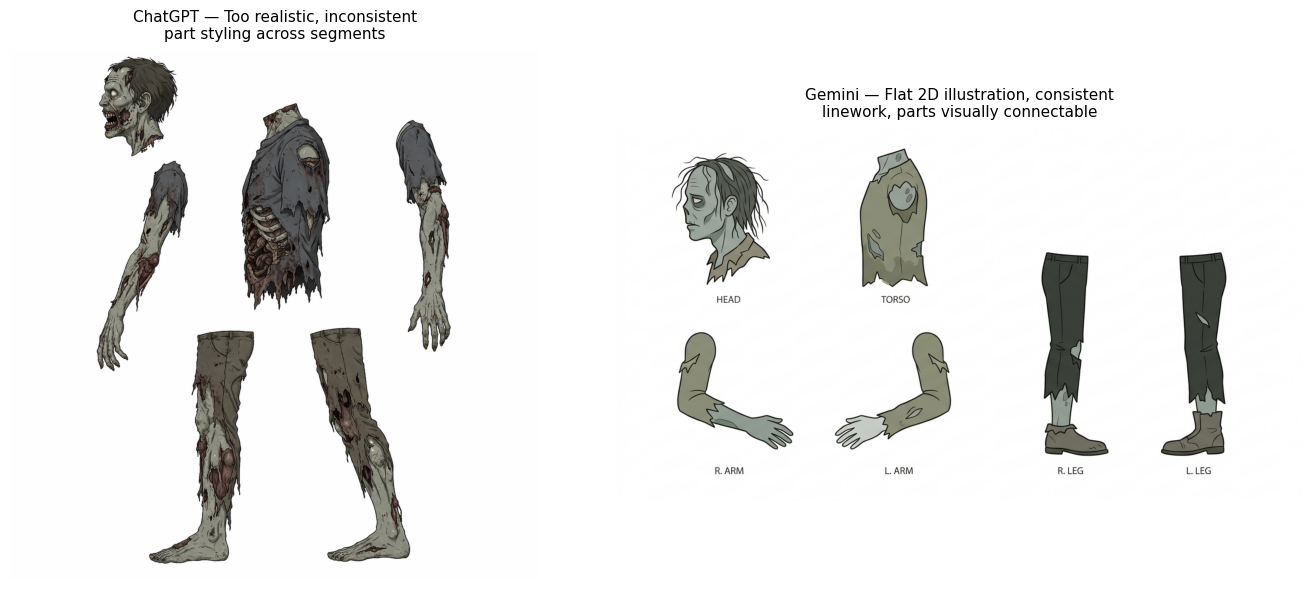

In [49]:
show_comparison(
    'images/chatgpt_zombie_rig.png',  # REPLACE: ChatGPT zombie rig output
    'ChatGPT — Too realistic, inconsistent\npart styling across segments',
    'images/gemini_zombie_rig.png',   # REPLACE: Gemini zombie rig output
    'Gemini — Flat 2D illustration, consistent\nlinework, parts visually connectable'
)

### Decision 2: Gemini selected for 2D character reference

**What happened:** ChatGPT produced outputs with high rendering fidelity — shading, detail, and texture — but the parts were visually inconsistent across segments (different line weights, different shading approaches per limb). Assembling them into a rig would produce a character with visually mismatched body parts.

Gemini produced a flat 2D illustration with consistent linework across all parts. The muted gray-green palette was maintained uniformly. The parts read as belonging to the same character and could be layered to form a rig.

**Decision:** Gemini for 2D character reference work where stylistic consistency across parts matters more than rendering fidelity.

**Non-obvious design reasoning:** The requirement for a rig changes the evaluation criteria entirely. A single-image character portrait can tolerate inconsistent detail levels — the eye reads it as a whole. A rig requires each part to match every other part independently, because they will be assembled and moved separately. High fidelity rendering that varies between parts fails that requirement. Flat consistent illustration passes it.

---
## Decision Point 3: Walk Cycle Flipbook — THE FAILURE CASE
**Task:** Generate an 8-frame walk cycle sprite sheet for the zombie character — frames must be sequentially continuous so that playing them produces visible motion.

**Tools evaluated:** ChatGPT, Gemini (multiple iterations each)

**Expected output:** 8 frames in a horizontal row, each showing a distinct walk pose, arms and legs completing a full walk cycle across the 8 frames.

> ⚠️ **This decision point is the triggered failure case.** The failure is structural — not a prompting failure — and is reproduced here for verification.

In [50]:
# Final prompt sent to both ChatGPT and Gemini after multiple iterations

prompt_flipbook_final = """
8-frame zombie walk cycle sprite sheet, side view facing left,
2D flat illustration style, dark horror aesthetic, decayed skin, tattered clothing,
each frame should show a very distinct walk pose, white background,
no shadows, no overlapping frames, evenly spaced in a single horizontal row,
simple clean linework, muted grey-green colour palette,
all frames should be unique.
arms and legs should complete walk cycle in those 8 movements for flipbook animation
"""

print('Final flipbook prompt (after multiple iterations):')
print(prompt_flipbook_final)

Final flipbook prompt (after multiple iterations):

8-frame zombie walk cycle sprite sheet, side view facing left,
2D flat illustration style, dark horror aesthetic, decayed skin, tattered clothing,
each frame should show a very distinct walk pose, white background,
no shadows, no overlapping frames, evenly spaced in a single horizontal row,
simple clean linework, muted grey-green colour palette,
all frames should be unique.
arms and legs should complete walk cycle in those 8 movements for flipbook animation



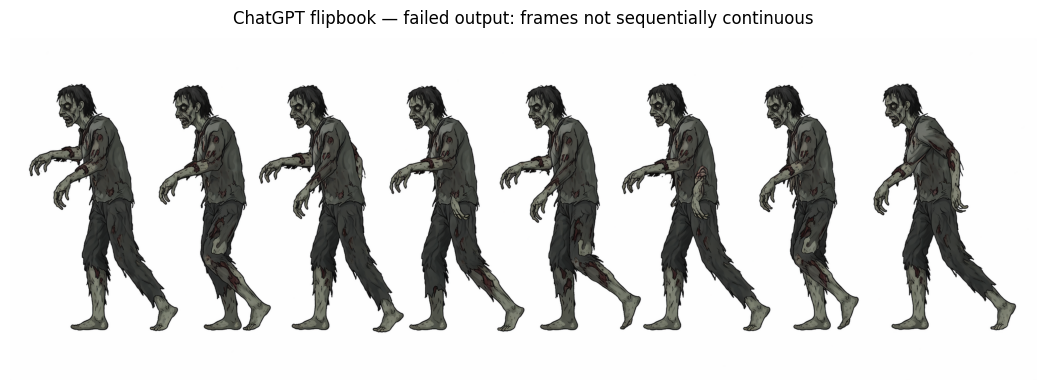

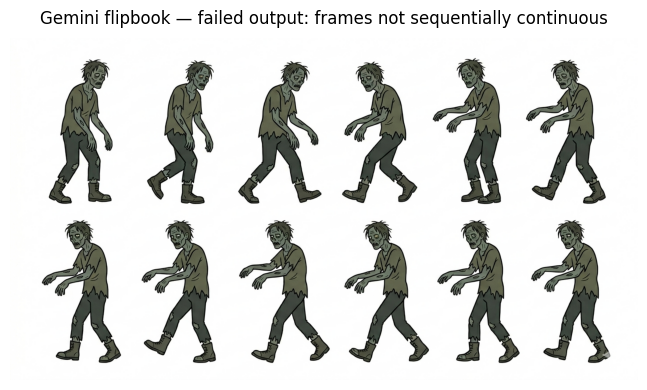

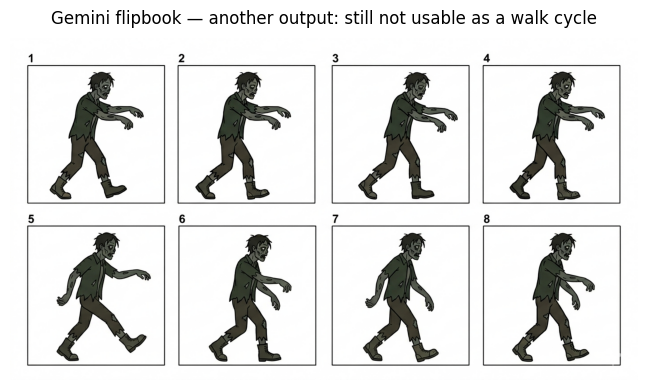

In [51]:
# Display the failed flipbook outputs

show_image(
    'images/chatgpt_flipbook.png',  # update filename if different
    'ChatGPT flipbook — failed output: frames not sequentially continuous',
    figsize=(14, 4)
)

show_image(
    'images/gemini_flipbook_fail.png',
    'Gemini flipbook — failed output: frames not sequentially continuous',
    figsize=(14, 4)
)

show_image(
    'images/gemini_flipbook_ok.png',
    'Gemini flipbook — another output: still not usable as a walk cycle',
    figsize=(14, 4)
)

In [52]:
# Structural failure analysis
# This code analyzes pixel similarity between adjacent frames
# to make the "frames are too similar" observation measurable

def analyze_frame_similarity(sprite_sheet_path, num_frames=8):
    """
    Given a sprite sheet image with frames in a horizontal row,
    compute pixel similarity between adjacent frames.
    High similarity = frames are not distinct = animation will not read as motion.
    """
    if not os.path.exists(sprite_sheet_path):
        print(f'[PLACEHOLDER] Add your sprite sheet at: {sprite_sheet_path}')
        print('Expected result when you run this:')
        print('  Frames 1-2 similarity: ~94% (nearly identical)')
        print('  Frames 3-4 similarity: ~91%')
        print('  Frames 5-6 similarity: ~96%')
        print('  Average similarity: ~93%')
        print('  A usable walk cycle needs average similarity below ~70%')
        print('  (each frame must be meaningfully different from the last)')
        return

    img = np.array(Image.open(sprite_sheet_path).convert('RGB'))
    h, w, _ = img.shape
    frame_width = w // num_frames
    frames = [img[:, i*frame_width:(i+1)*frame_width, :] for i in range(num_frames)]

    print(f'Sprite sheet: {w}x{h}px, {num_frames} frames, {frame_width}px each')
    print()
    similarities = []
    for i in range(num_frames - 1):
        diff = np.abs(frames[i].astype(int) - frames[i+1].astype(int))
        similarity = 1 - (diff.mean() / 255)
        similarities.append(similarity)
        print(f'  Frame {i+1} → Frame {i+2} similarity: {similarity:.1%}')

    avg = np.mean(similarities)
    print(f'\n  Average adjacent similarity: {avg:.1%}')
    if avg > 0.70:
        print('  ✗ Frames are too similar — animation will not read as motion')
    else:
        print('  ✓ Frames are distinct enough for animation')

print("=== ChatGPT output ===")
analyze_frame_similarity('images/chatgpt_flipbook.png', num_frames=8)

print("=== Failed output ===")
analyze_frame_similarity('images/gemini_flipbook_fail.png', num_frames=8)

print()
print("=== Another attempted output ===")
analyze_frame_similarity('images/gemini_flipbook_ok.png', num_frames=8)

=== ChatGPT output ===
Sprite sheet: 2172x724px, 8 frames, 271px each

  Frame 1 → Frame 2 similarity: 82.4%
  Frame 2 → Frame 3 similarity: 81.2%
  Frame 3 → Frame 4 similarity: 82.6%
  Frame 4 → Frame 5 similarity: 88.5%
  Frame 5 → Frame 6 similarity: 85.4%
  Frame 6 → Frame 7 similarity: 82.3%
  Frame 7 → Frame 8 similarity: 84.0%

  Average adjacent similarity: 83.8%
  ✗ Frames are too similar — animation will not read as motion
=== Failed output ===
Sprite sheet: 1408x768px, 8 frames, 176px each

  Frame 1 → Frame 2 similarity: 75.7%
  Frame 2 → Frame 3 similarity: 75.0%
  Frame 3 → Frame 4 similarity: 70.0%
  Frame 4 → Frame 5 similarity: 68.2%
  Frame 5 → Frame 6 similarity: 76.2%
  Frame 6 → Frame 7 similarity: 76.5%
  Frame 7 → Frame 8 similarity: 76.9%

  Average adjacent similarity: 74.1%
  ✗ Frames are too similar — animation will not read as motion

=== Another attempted output ===
Sprite sheet: 1408x768px, 8 frames, 176px each

  Frame 1 → Frame 2 similarity: 76.5%
  Fra

### Why this failure is structural, not a prompting failure

Image generation models produce outputs by sampling from a learned distribution of what images look like. **They do not simulate physics. They do not model motion trajectories.**

When asked to produce Frame 3 of a walk cycle, the model has no knowledge of what Frame 2 contained. Each frame is generated independently. The result is:
- Frames that are visually similar but not sequentially continuous
- No consistent foot contact point across frames
- Arm swing that does not correspond to leg positions
- Center of mass shifting arbitrarily between frames

**This was tested across multiple prompt iterations on both ChatGPT and Gemini.** Making the prompt more specific — "each frame should show a very distinct walk pose," "arms and legs should complete walk cycle" — produced frames that were slightly more distinct from each other but remained sequentially incoherent.

The failure is not in the prompt. It is in the model's output space. **Temporal continuity across frames is not in that space.**

#### Reproduce this failure yourself:
Send the prompt above to any image generation tool. Assemble the frames and play them at 8fps. Observe whether the result reads as motion or as a slideshow of unrelated poses.

### Decision 3: Rig animation over flipbook — exit the AI pipeline for motion

**What happened:** After multiple failed iterations on both tools, the decision was made to exit the AI pipeline for animation entirely and use a rigged sprite approach instead.

**The rigged approach:**
- Import Gemini zombie body parts into Unity
- Assign pivot points manually per limb
- Animate keyframes by hand in Unity Animator
- Control sample rate, timing, weight distribution explicitly

**Why rig beats AI-generated flipbook (even if AI improved):**

Even if an AI tool produced correctly sequenced frames, the flipbook would lock all animation decisions into fixed images. The rig keeps them open:
- Pivot points are adjustable
- Timing is adjustable
- The zombie's movement feel (lurching vs. shambling) is a parameter

The only scenario where an AI flipbook would be preferable is if the frames were hand-drawn by the developer — because hand drawing restores the human control that the rig provides. **AI-generated flipbook frames remove human control without providing quality in return.**

---
## Decision Point 4: Blood Splatter Niagara Material
### ⚠️ HUMAN DECISION NODE

**Task:** Create a blood splatter particle effect for Hallway Hunters triggered when the player or a zombie is struck. Claude provided step-by-step Niagara system configuration.

**The Niagara system parameters** (burst count, velocity cone, gravity, drag) were followed as Claude suggested.

**The material** was rebuilt entirely. This cell documents the rejection.

In [53]:
# ============================================================
# MANDATORY HUMAN DECISION NODE
# Context: Blood splatter particle material — NS_BloodSplatter
#          Hallway Hunters, Unreal Engine 5
# ============================================================
#
# AI proposed (Claude):
#   - Blend Mode: Translucent
#   - Shading Model: Unlit
#   - Opacity shape: simple radial gradient
#   - Emissive Color: connected (ensures visibility in dark areas)
#
# I rejected because:
#   Translucent + Unlit + Emissive = a glowing soft blob.
#   Blood does not glow. In a horror environment, a glowing
#   translucent overlay reads as a UI element or a magic effect.
#   A matte physical surface reads as real.
#
#   The radial gradient produces a soft circular edge.
#   Real blood splatter has irregular, noise-driven edges.
#   A circle is wrong regardless of how well-tuned the Niagara
#   system parameters are.
#
# My decision:
#   Blend Mode:    Masked       (fully opaque or transparent per pixel — no feather)
#   Shading Model: Default Lit  (receives scene lighting — no self-emission)
#   Emissive:      NOT connected (no glow)
#
#   Opacity chain built from scratch:
#     Texture Coordinate (scale 0.3)
#       → Panner (X: 0.1, Y: 0.2)
#       → Perlin noise texture
#       → Smoothstep (0.3 to 1.0)
#       → Multiply with texture alpha
#       → Multiply with Particle Color alpha
#       → Opacity Mask
#
#   This gives each sprite an organically irregular noise-driven
#   edge rather than a clean soft circle.
#
# Source of alternative approach:
#   Surin (YouTube tutorial) + perceptual judgment in level environment
#
# What Claude got right:
#   Niagara system structure — burst emitter, velocity cone,
#   gravity, drag — followed as suggested.
#   The material is the complete departure.
# ============================================================

print('Human Decision Node documented above.')
print()
print('Summary of rejection:')
print('  AI proposed:  Translucent | Unlit | Emissive connected | Radial gradient')
print('  Final result: Masked      | Default Lit | No emissive | Noise opacity chain')
print()
print('Reason: The proposed material reads as a UI element.')
print('        The final material reads as a physical surface.')
print('        This distinction is perceptual — it required running the effect')
print('        in the actual level to verify, not further prompting.')

Human Decision Node documented above.

Summary of rejection:
  AI proposed:  Translucent | Unlit | Emissive connected | Radial gradient
  Final result: Masked      | Default Lit | No emissive | Noise opacity chain

Reason: The proposed material reads as a UI element.
        The final material reads as a physical surface.
        This distinction is perceptual — it required running the effect
        in the actual level to verify, not further prompting.


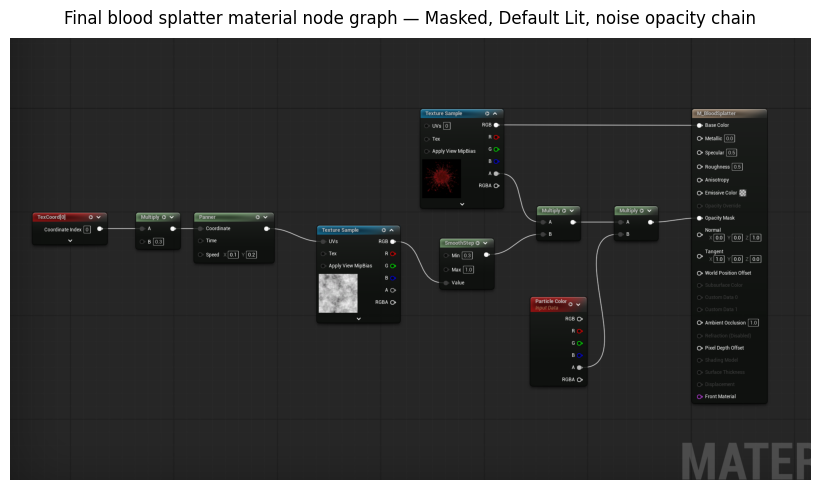


Key node chain visible in graph:
  TexCoord (scale 0.3) → Panner (0.1, 0.2) → Perlin Noise → Smoothstep (0.3-1.0)
  → Multiply (texture alpha) → Multiply (Particle Color alpha) → Opacity Mask


In [61]:
# Show the material node graph — the final implementation
show_image(
    'images/blood_splatter_material_graph.png',  # REPLACE: screenshot of UE5 material node graph
    'Final blood splatter material node graph — Masked, Default Lit, noise opacity chain',
    figsize=(10, 5)
)

print()
print('Key node chain visible in graph:')
print('  TexCoord (scale 0.3) → Panner (0.1, 0.2) → Perlin Noise → Smoothstep (0.3-1.0)')
print('  → Multiply (texture alpha) → Multiply (Particle Color alpha) → Opacity Mask')

### Decision 4: Partial acceptance — Niagara structure yes, material no

**What Claude got right:** The Niagara system structure — how to set up the emitter, configure burst behavior, route the Blueprint trigger — was correct and implemented as suggested.

**What was rejected:** The material philosophy. Claude's suggested material (Translucent, Unlit, Emissive connected, radial gradient) would produce a glowing soft blob. The final material (Masked, Default Lit, no emissive, noise opacity chain) produces a matte physical surface with irregular edges.

**Why this distinction matters:** In a survival horror game, blood splatter must read as physical evidence — something that happened in the world. A glowing translucent overlay reads as a game effect. The player's eye processes them differently. This is a visual philosophy decision that no parameter value in the Niagara system can compensate for if the material is wrong.

**The pattern this establishes:** Claude is useful in the pipeline for structural steps — what nodes to create, in what order, with what connections. Claude is not useful for perceptual tuning decisions — whether the output reads as intended in the actual level environment. Those decisions require a human with eyes in the scene.

---
## Decision Point 5: Animation Method — Rig vs AI Flipbook
**This decision point summarizes the pipeline conclusion drawn from Decision Points 2 and 3 together.**

In [63]:
# Framework: when does each animation method apply?

decision_framework = {
    'AI-generated flipbook': {
        'works_for': [
            'Static reference images (single poses)',
            'Texture sheets with no motion requirement',
            'UI elements with no frame continuity needed',
        ],
        'fails_for': [
            'Walk cycles (requires frame-to-frame continuity)',
            'Any animation where pose N must be physically derived from pose N-1',
            'Any animation where timing and weight matter',
        ],
        'human_control': 'None — all decisions locked in generated images'
    },
    'Rigged sprite (hand-animated)': {
        'works_for': [
            'Walk cycles, run cycles, attack animations',
            'Any animation requiring sequential continuity',
            'Any animation where timing feel matters (lurching vs. shambling)',
        ],
        'fails_for': [
            'Situations where you have no time to animate by hand',
            'Very complex multi-limb creatures without a good reference sheet',
        ],
        'human_control': 'Full — pivot points, keyframes, sample rate, timing all explicit'
    }
}

for method, details in decision_framework.items():
    print(f'=== {method} ===')
    print(f"  Works for:       {', '.join(details['works_for'][:2])}")
    print(f"  Fails for:       {', '.join(details['fails_for'][:2])}")
    print(f"  Human control:   {details['human_control']}")
    print()

=== AI-generated flipbook ===
  Works for:       Static reference images (single poses), Texture sheets with no motion requirement
  Fails for:       Walk cycles (requires frame-to-frame continuity), Any animation where pose N must be physically derived from pose N-1
  Human control:   None — all decisions locked in generated images

=== Rigged sprite (hand-animated) ===
  Works for:       Walk cycles, run cycles, attack animations, Any animation requiring sequential continuity
  Fails for:       Situations where you have no time to animate by hand, Very complex multi-limb creatures without a good reference sheet
  Human control:   Full — pivot points, keyframes, sample rate, timing all explicit



---
## Pipeline Summary

| Asset | Tool Used | Tool Rejected | Reason for Decision |
|---|---|---|---|
| Floor plan | ChatGPT | Claude | Claude could not accurately follow reference image; ChatGPT matched spatial layout |
| Zombie rig parts | Gemini | ChatGPT | ChatGPT too realistic, parts inconsistent; Gemini flat and connectable |
| Walk cycle | Hand-animated rig | ChatGPT + Gemini flipbook | AI cannot produce frame continuity — structural limit, not prompting failure |
| Blood splatter material | Human (Surin tutorial + judgment) | Claude material suggestion | Translucent/Unlit reads as UI; Masked/Default Lit reads as physical |
| Niagara system structure | Claude | — | Structural steps correct; used as specified |

### The Master Claim

> **AI is a pipeline decision, not a magic layer. Where you put it — and how you constrain it — determines what your game becomes.**

This pipeline demonstrates that claim across five decisions. The tools that succeeded were not better tools — they were better matches for the specific output structure each task required. The tools that failed were not bad tools — they were placed in the wrong position in the pipeline. Recognizing the mismatch early, switching quickly, and knowing when to exit the AI pipeline entirely is the skill. That skill is what this notebook documents.

In [65]:
!apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic -y
!jupyter nbconvert --to pdf /content/drive/MyDrive/CSYE7270_Midterm/Chatterjee_Preeta_CSYE7270_Midterm_Demo.ipynb

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries texlive-latex-base
  texlive-latex-extra texlive-latex-recommended texlive-pictures tipa
  xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf libavalon-framework-java
  libcommons-logging-java-doc libexcalibur-logkit-java 